In [1]:
import pandas as pd 

In [2]:
td = pd.read_csv("titanic.csv")


In [3]:
td.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
td = td.drop("PassengerId" , axis=1)
#!there is no need for indexing here ! has no relation whith whom survived 

In [5]:
td.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB


In [6]:
td.isna().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [7]:
td = td.drop("Cabin", axis=1) 
#! like 200 info from an 800 !! which doesnt add thing !!

In [8]:
td.isna().sum() # typed again to check if deleted or not !!

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Embarked      2
dtype: int64

In [9]:
td = td.drop(["Name" , "Embarked", "Ticket"], axis=1)
#! here the name has no indication of whethter the person survived or not and the embarktion also has no relation which is where the person got boarded and same for ticket !

In [10]:
td.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500


In [11]:
td["Age"] = td["Age"].fillna(method ="ffill")

C:\Users\Ahmed\AppData\Local\Temp\ipykernel_3712\1160606780.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  td["Age"] = td["Age"].fillna(method ="ffill")


In [12]:
td.isna().sum() 

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
dtype: int64

In [ ]:
td["Survived"].astype("int32").mean()
# i find this no usefull as it is the percentage of the survived !! or could just do .sum() !!

np.float64(0.3838383838383838)

In [14]:
import matplotlib.pyplot as plt


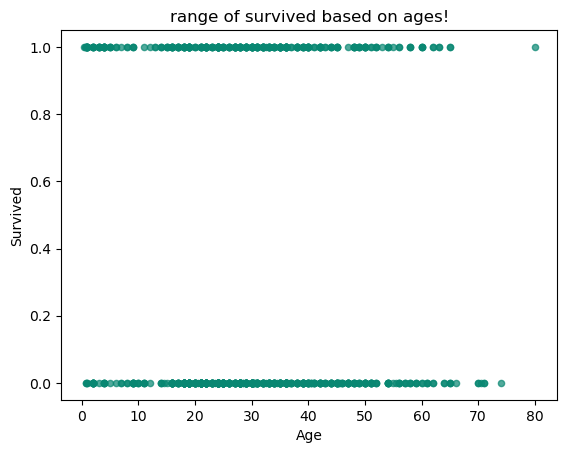

In [15]:
td.plot(kind="scatter", x = "Age"  , y = "Survived" , color = "#098772", alpha = 0.7 , title="range of survived based on ages!")
plt.show()

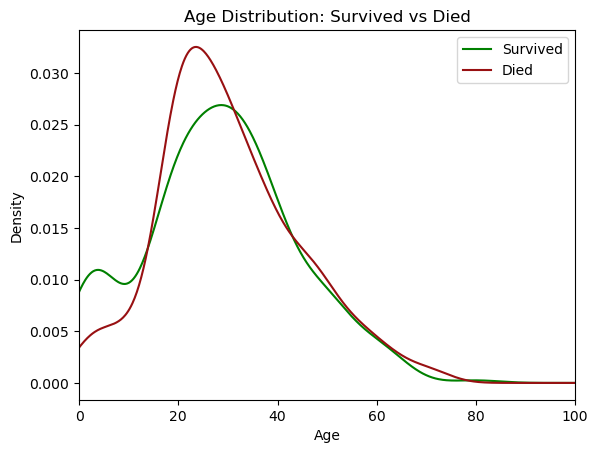

In [16]:
td[td['Survived'] == 1]['Age'].plot(kind='kde', label='Survived', color='green')
td[td['Survived'] == 0]['Age'].plot(kind='kde', label='Died', color='#981012')
# here i asked ai what is the parameters of the kde cause i dont know it and how to adjust it !!!
plt.xlabel('Age')
plt.title('Age Distribution: Survived vs Died')
plt.xlim(0,100)
plt.legend()

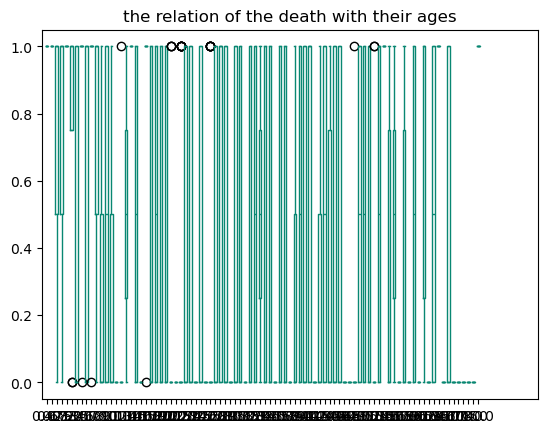

In [17]:
td.plot(kind="box", color = "#098772", column = "Survived" , by ="Age" , grid=False)
plt.title("the relation of the death with their ages")
plt.xlim(0,100)
plt.show()
# here i asked ai what is the parameters of the box cause i dont know it and how to adjust it !!!


In [18]:
# here i spent time trying to figure the best graph to this part but i couldn't find one !! like for me kde is the best yet and it shows that the death ages are random they actually overlap between the survived too !!!

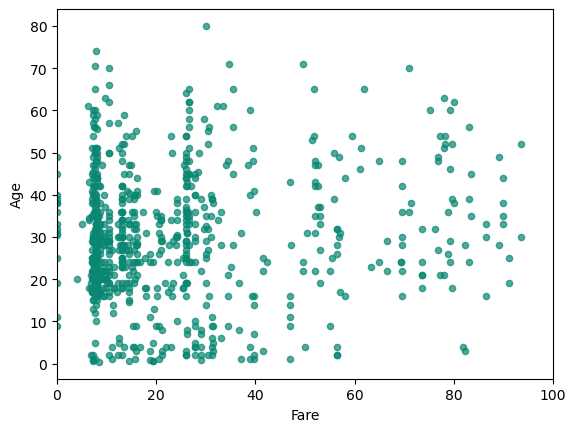

In [19]:
td.plot(kind="scatter", x = "Fare"  , y = "Age" , alpha=0.7 , color = "#098772")
plt.xlim(0,100)
plt.show()

In [20]:
# the upper graph is important as it relates the class with age , with implies where the person was at the start of the incident 

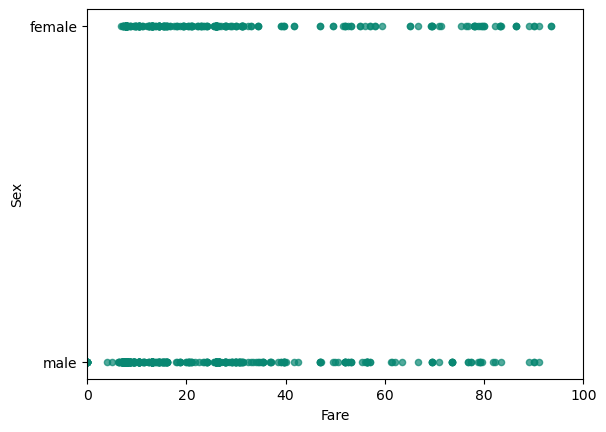

In [21]:
td.plot(kind="scatter", x = "Fare"  , y = "Sex" , color = "#098772", alpha = 0.7 )
plt.xlim(0,100)
plt.show()

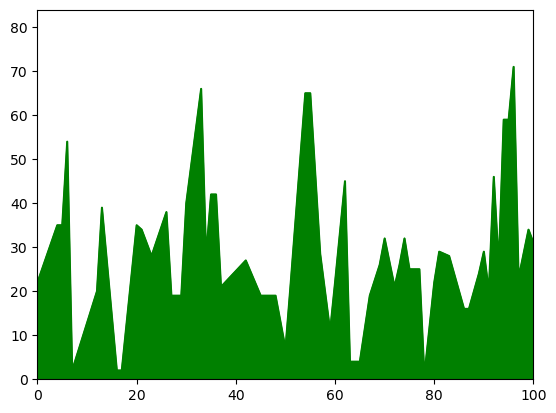

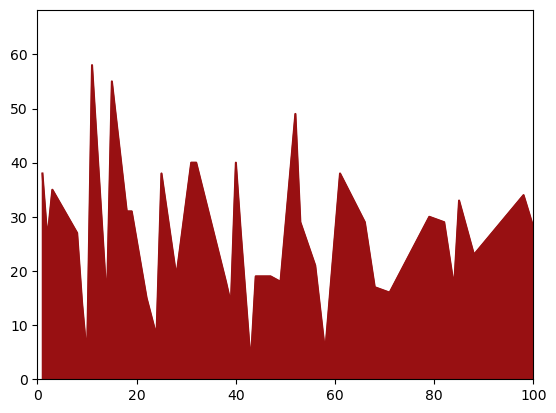

In [22]:
td[td['Sex'] == "male"]['Age'].plot(kind="area", color='green')
plt.xlim(0,100)
plt.show()

td[td['Sex'] == "female"]['Age'].plot(kind='area',  color='#981012')
plt.xlim(0,100)
plt.show()

In [ ]:
td.drop("Sex" , axis=1).corr()
#? here i dropped the Sex column as it is an object and gave me an error without dropping it !!

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.065571,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.291157,0.083081,0.018443,-0.549500
Age,-0.065571,-0.291157,1.000000,-0.206104,-0.165191,0.083417
SibSp,-0.035322,0.083081,-0.206104,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.165191,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.083417,0.159651,0.216225,1.000000


In [24]:
# here the correlation is very important to understand which matches with whom , although i can't see any highly correlated with another !!